In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


        ua     ui
52   0.025  0.025
84   0.025  0.030
81   0.025  0.110
26   0.025  0.150
8    0.025  0.190
4    0.025  0.240
44   0.030  0.025
56   0.030  0.030
100  0.030  0.110
76   0.030  0.150
13   0.030  0.190
14   0.030  0.240
193  0.040  0.025
205  0.040  0.030
151  0.040  0.110
190  0.040  0.150
144  0.040  0.190
68   0.040  0.240
282  0.045  0.025
283  0.045  0.030
221  0.045  0.110
168  0.045  0.150
198  0.045  0.190
134  0.045  0.240
16   0.049  0.025
128  0.049  0.030
290  0.049  0.110
266  0.049  0.150
215  0.049  0.190


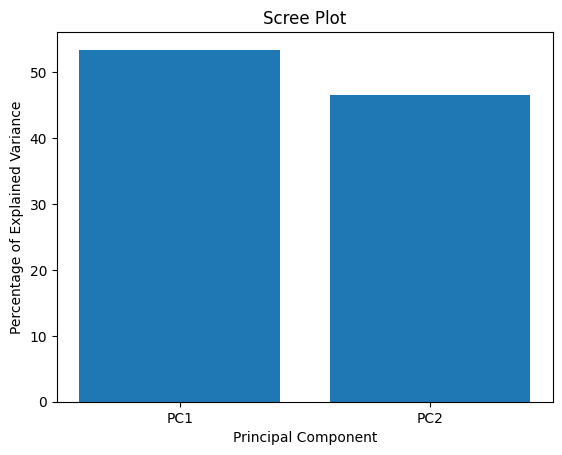

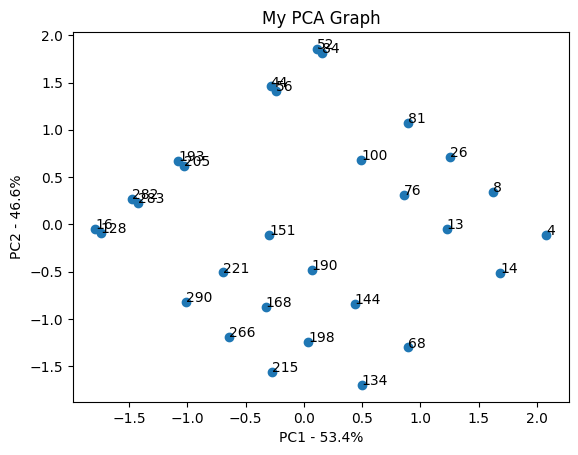

ua   -0.707107
ui    0.707107
dtype: float64


In [ ]:
# Using image data as the labels

import pandas as pd
import openpyxl
from sklearn import preprocessing
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

ua = []
ui = []
num_spots = []
total_coverage = []
avg_spot_size = []
spot_size_std = []
avg_circ = []
circ_std = []



wb = openpyxl.load_workbook(filename = "/content/drive/Shareddrives/Summer_2023_VCell_Ml/Summer 2023  Image analysis/Ua vs Ui Data/Final Data Raw.xlsx")
ws = wb.active # Get workbook active sheet object from active attribute

# extracts data from excel
for i in range(2, ws.max_row):
    ua.append(ws.cell(row=i, column=2).value)
    ui.append(ws.cell(row=i, column=3).value)
    num_spots.append(ws.cell(row=i, column=4).value)
    total_coverage.append(ws.cell(row=i, column=5).value)
    avg_spot_size.append(ws.cell(row=i, column=6).value)
    spot_size_std.append(ws.cell(row=i, column=7).value)
    avg_circ.append(ws.cell(row=i, column=8).value)
    circ_std.append(ws.cell(row=i, column=9).value)

Y = num_spots

ua_div_ui = []
for i in range(len(ui)):
    ua_div_ui.append(ua[i]/ui[i])

data = pd.DataFrame(index = Y)


names = ["ua","ui"]
categories = [ua,ui]

for j in range(len(categories)):
    data[names[j]] = categories[j]

print(data)
scaled_data = preprocessing.scale(data)

# print(scaled_data)

pca = PCA()

pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)

#Scree Plot
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var) + 1)]

plt.bar(x=range(1, len(per_var) + 1), height=per_var, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

# the following code makes a fancy looking plot using PC1 and PC2
pca_df = pd.DataFrame(pca_data, index= Y, columns = labels)

plt.scatter(pca_df.PC1, pca_df.PC2)
plt.title('My PCA Graph')
plt.xlabel('PC1 - {0}%'.format(per_var[0]))
plt.ylabel('PC2 - {0}%'.format(per_var[1]))

for sample in pca_df.index:
    plt.annotate(sample, (pca_df.PC1.loc[sample], pca_df.PC2.loc[sample]))

plt.show()

## get the name of the top 10 measurements (genes) that contribute
## most to pc1.
## first, get the loading scores
loading_scores = pd.Series(pca.components_[0], index=names)
## now sort the loading scores based on their magnitude
sorted_loading_scores = loading_scores.abs().sort_values(ascending=False)

# get the names of the top 10 genes
top_n = sorted_loading_scores[0:6].index.values

## print the gene names and their scores (and +/- sign)
print(loading_scores[top_n])